In [ ]:
print("Weights Concepts".center(100,'-'))
concepts = '''1. Weight matrix dimensions = nodes in current layer x nodes in previous layer\n
2. Models cannot learn when all trainable parameters are initalized to the same value
3. Models can learn as long as some trainable parameters are initialized to different numbers.

'''
print(concepts)

------------------------------------------Weights Concepts------------------------------------------
1. Weight matrix dimensions = nodes in current layer x nodes in previous layer

2. Models cannot learn when all trainable parameters are initalized to the same value
3. Models can learn as long as some trainable parameters are initialized to different numbers.




In [ ]:
import torch
import torch.nn as nn

In [ ]:
print("Model 1".center(100,'-'))
model_1 = nn.Sequential(
    nn.Linear(10,14), #input layer
    nn.Linear(14,19), #hidden layer
    nn.Linear(19,8) #output layer
)

print(model_1)

for i in range(len(model_1)):
  print(model_1[i].weight.shape)

print("Model 2".center(100,'-'))

model_2 = nn.Sequential(
    nn.Linear(10,14), #input layer
    nn.Linear(14,9), #hidden layer
    nn.Linear(19,8) #output layer
)
print(model_2)

for i in range(len(model_2)):
  print(model_2[i].weight.shape)

print("Model 3".center(100,'-'))
model_3 = nn.Sequential(
    nn.Linear(2,3), #input layer
    nn.Linear(3,3), #hidden layer
    nn.Linear(3,1) #output layer
)

print(model_3)

for i in range(len(model_1)):
  print(model_3[i].weight.shape)


----------------------------------------------Model 1-----------------------------------------------
Sequential(
  (0): Linear(in_features=10, out_features=14, bias=True)
  (1): Linear(in_features=14, out_features=19, bias=True)
  (2): Linear(in_features=19, out_features=8, bias=True)
)
torch.Size([14, 10])
torch.Size([19, 14])
torch.Size([8, 19])
----------------------------------------------Model 2-----------------------------------------------
Sequential(
  (0): Linear(in_features=10, out_features=14, bias=True)
  (1): Linear(in_features=14, out_features=9, bias=True)
  (2): Linear(in_features=19, out_features=8, bias=True)
)
torch.Size([14, 10])
torch.Size([9, 14])
torch.Size([8, 19])
----------------------------------------------Model 3-----------------------------------------------
Sequential(
  (0): Linear(in_features=2, out_features=3, bias=True)
  (1): Linear(in_features=3, out_features=3, bias=True)
  (2): Linear(in_features=3, out_features=1, bias=True)
)
torch.Size([3, 2])


In [ ]:
nsamples = 5
nfeatures = 10

testdata = torch.randn(nsamples,nfeatures)
testdata.shape

model_1(testdata).shape
#model_2(testdata) #throws an error due to incorrect node sizes

torch.Size([5, 8])

In [ ]:
nsamples = 5
nfeatures = 2

testdata = torch.randn(nsamples,nfeatures)
print("/*Input data & its shape*/")
print(testdata.shape)
print(testdata)
W = []
print("\n/*Weights & Biases*/")
for i in range(len(model_3)):
  print(f"Layer {i}")
  for name, params in model_3[i].named_parameters():
    print(f"{name} = {params}")
    W.append(params)

print("\n/*Output*/")
print(model_3(testdata))

print("\n/*Replciating result using matrix multiplication*/")
print(" This is essentially xwT")
for i in range(testdata.shape[0]):
  print(torch.matmul(torch.matmul(torch.matmul(testdata[i], W[0].T) + W[1],W[2].T)+ W[3],W[4].T) + W[5])

/*Input data & its shape*/
torch.Size([5, 2])
tensor([[-0.7983, -0.0709],
        [ 1.0289, -0.6694],
        [ 2.0965, -1.0992],
        [ 0.9842,  0.8673],
        [ 0.0845,  1.0904]])

/*Weights & Biases*/
Layer 0
weight = Parameter containing:
tensor([[ 0.4091,  0.6983],
        [ 0.4286, -0.2330],
        [-0.5018, -0.5387]], requires_grad=True)
bias = Parameter containing:
tensor([ 0.4695,  0.4695, -0.3978], requires_grad=True)
Layer 1
weight = Parameter containing:
tensor([[-0.0243, -0.2408, -0.4044],
        [-0.0557, -0.3447,  0.0274],
        [ 0.1024,  0.5206, -0.4180]], requires_grad=True)
bias = Parameter containing:
tensor([ 0.2902, -0.0982,  0.5262], requires_grad=True)
Layer 2
weight = Parameter containing:
tensor([[-0.5141,  0.2251, -0.1529]], requires_grad=True)
bias = Parameter containing:
tensor([-0.5636], requires_grad=True)

/*Output*/
tensor([[-0.8103],
        [-1.0116],
        [-1.1169],
        [-1.2394],
        [-1.1293]], grad_fn=<AddmmBackward0>)

/*Replc

In [ ]:
testdata.shape[0]

5

#msnist and initializations

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch.nn.functional as F
from torch.utils.data import DataLoader

from sklearn.model_selection import train_test_split

label of image in row no 951 : 9


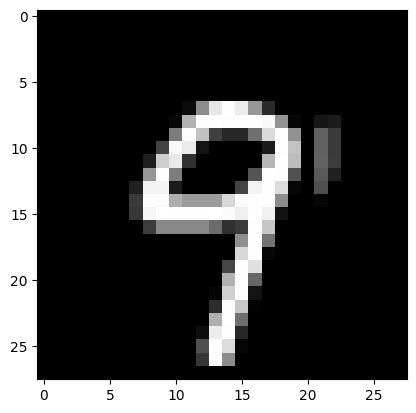

In [ ]:
data = np.loadtxt(open("/content/sample_data/mnist_train_small.csv"),delimiter=',')
data.shape #28 x 28 + label

i = 951
print(f"label of image in row no {i} :", int(data[i-1][0]))
plt.imshow(data[i-1][1:].reshape(28,28), cmap='gray')

labels = data[:,0]
data = data[:,1:]

In [ ]:
print(f"Pre Normalization : data min value {data.min()}, data max value {data.max()}")

#normalize data
dataNorm = data/data.max()
print(f"Post Normalization : data min value {dataNorm.min()}, data max value {dataNorm.max()}")

#convert to tensor
dataT = torch.tensor(dataNorm).float()
labelsT = torch.tensor(labels).long() # Convert labels to long type (integer)

#train test split
train_data,test_data, train_labels,test_labels = train_test_split(dataT, labelsT, test_size=.1)
print(train_data.shape, train_labels.shape)
print(test_data.shape, test_labels.shape)

#convert into PyTorch Datasets
train_data = torch.utils.data.TensorDataset(train_data,train_labels)
test_data  = torch.utils.data.TensorDataset(test_data,test_labels)

#dataloader objects
batchsize    = 32
train_loader = DataLoader(train_data,batch_size=batchsize,shuffle=True,drop_last=True)
test_loader  = DataLoader(test_data,batch_size=test_data.tensors[0].shape[0])

Pre Normalization : data min value 0.0, data max value 255.0
Post Normalization : data min value 0.0, data max value 1.0
torch.Size([18000, 784]) torch.Size([18000])
torch.Size([2000, 784]) torch.Size([2000])


In [ ]:
#define the model
def mnist_1():

  class mnist_1(nn.Module):
    def __init__(self):
      super().__init__()

      ### input layer
      self.input = nn.Linear(784,64)

      ### hidden layer
      self.fc1 = nn.Linear(64,32)
      self.fc2 = nn.Linear(32,32)

      ### output layer
      self.output = nn.Linear(32,10)

    # forward pass
    def forward(self,x):
      x = F.relu( self.input(x) )
      x = F.relu( self.fc1(x) )
      x = F.relu( self.fc2(x) )
      return self.output(x)

  # create the model instance
  model = mnist_1()

  # loss function
  lossfun = nn.CrossEntropyLoss()

  # optimizer
  optimizer = torch.optim.Adam(model.parameters(),lr=.01)

  return model,lossfun,optimizer

In [ ]:
model_1 = mnist_1()[0]
print(model_1)

print('\nWeight shapes of submodules:')
for name, module in model_1.named_children():
  if hasattr(module, 'weight'):
    print(f"  {name}: {module.weight.shape}")

print('\n\nWeights for layer fc1:')
print(model_1.fc1.weight.data)

mnist_1(
  (input): Linear(in_features=784, out_features=64, bias=True)
  (fc1): Linear(in_features=64, out_features=32, bias=True)
  (fc2): Linear(in_features=32, out_features=32, bias=True)
  (output): Linear(in_features=32, out_features=10, bias=True)
)

Weight shapes of submodules:
  input: torch.Size([64, 784])
  fc1: torch.Size([32, 64])
  fc2: torch.Size([32, 32])
  output: torch.Size([10, 32])


Weights for layer fc1:
tensor([[ 0.0948, -0.0370, -0.1028,  ...,  0.0221, -0.0708, -0.1009],
        [ 0.0144, -0.0657, -0.0602,  ..., -0.0709, -0.0447, -0.0603],
        [ 0.0276,  0.1186,  0.1066,  ...,  0.0754, -0.0365, -0.0737],
        ...,
        [-0.0321,  0.0038, -0.0121,  ...,  0.0752,  0.1075, -0.0487],
        [ 0.0677, -0.1247, -0.0233,  ..., -0.0384, -0.0875,  0.0383],
        [ 0.0307, -0.0138, -0.0501,  ...,  0.0570,  0.0078,  0.0411]])


In [ ]:
def train_1(model,lossfun,optimizer):

  # number of epochs
  numepochs = 10

  # initialize losses
  losses    = torch.zeros(numepochs)
  trainAcc  = []
  testAcc   = []


  # loop over epochs
  for epochi in range(numepochs):

    # switch on train mode
    model.train()

    # loop over training data batches
    batchAcc  = []
    batchLoss = []
    for X,y in train_loader:

      # forward pass and loss
      yHat = model(X)
      loss = lossfun(yHat,y)

      # backprop
      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

      # loss from this batch
      batchLoss.append(loss.item())

      # compute accuracy
      matches = torch.argmax(yHat,axis=1) == y     # booleans (false/true)
      matchesNumeric = matches.float()             # convert to numbers (0/1)
      accuracyPct = 100*torch.mean(matchesNumeric) # average and x100
      batchAcc.append( accuracyPct )               # add to list of accuracies
    # end of batch loop...

    # now that we've trained through the batches, get their average training accuracy
    trainAcc.append( np.mean(batchAcc) )

    # and get average losses across the batches
    losses[epochi] = np.mean(batchLoss)

    # test accuracy
    model.eval()
    X,y = next(iter(test_loader)) # extract X,y from test dataloader
    with torch.no_grad(): # deactivates autograd
      yHat = model(X)

    # compare the following really long line of code to the training accuracy lines
    testAcc.append( 100*torch.mean((torch.argmax(yHat,axis=1)==y).float()) )
  # end epochs

  # function output
  return trainAcc,testAcc,losses,model

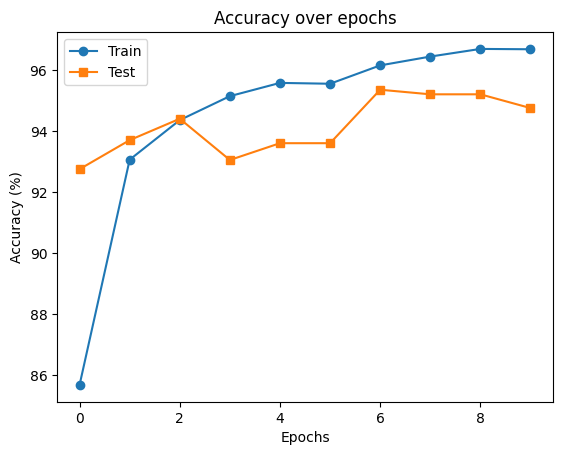

In [ ]:
# Run the model without changing the weights; this will be the baseline performance.
# Notice the model creation is outside the training
net_base,lossfun,optimizer = mnist_1()
trainAcc_base,testAcc_base,losses,net_base = train_1(net_base,lossfun,optimizer)

# plot the results
plt.plot(range(len(trainAcc_base)),trainAcc_base,'o-', range(len(testAcc_base)),testAcc_base ,'s-')
plt.legend(['Train','Test'])
plt.title('Accuracy over epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.show()

In [ ]:
# Change the weights before training
net_zero,lossfun,optimizer = mnist_1()

# set to zeros
net_zero.fc1.weight.data = torch.zeros_like( net_zero.fc1.weight )

# confirm
net_zero.fc1.weight.data

tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]])

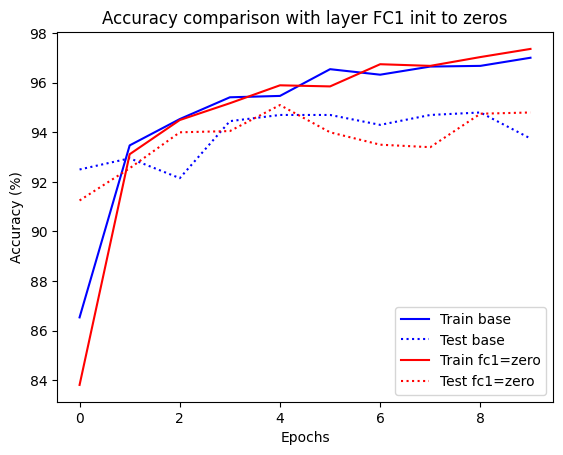

In [ ]:
# run the model and show the results
trainAcc_zero,testAcc_zero,losses,net_zero = train_1(net_zero,lossfun,optimizer)

plt.plot(range(len(trainAcc_base)),trainAcc_base,'b-', range(len(testAcc_base)),testAcc_base ,'b:')
plt.plot(range(len(trainAcc_zero)),trainAcc_zero,'r-', range(len(testAcc_zero)),testAcc_zero ,'r:')
plt.legend(['Train base','Test base','Train fc1=zero','Test fc1=zero'])
plt.title('Accuracy comparison with layer FC1 init to zeros')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.show()

tensor([[-0.4295,  0.3668, -1.0065,  ..., -0.0307, -0.0065,  0.6294],
        [ 0.5118,  0.2166,  0.1978,  ..., -0.0119,  0.1498, -0.3547],
        [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
        ...,
        [-0.4959,  0.6937, -0.3028,  ..., -0.0308, -0.2371, -1.2981],
        [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
        [ 0.6563, -0.7657, -0.6885,  ..., -0.0178, -0.7003, -0.2910]])


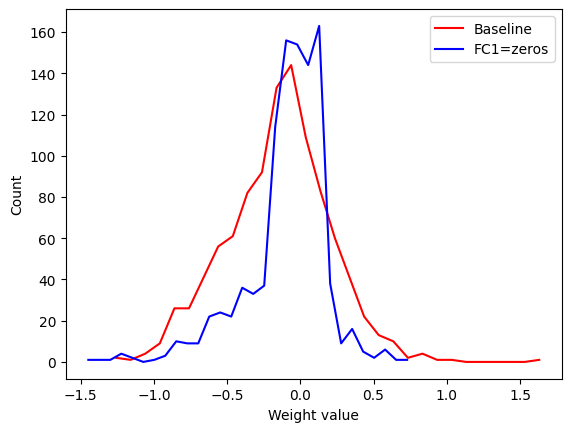

In [ ]:
# Are the weights still zeros?
print(net_zero.fc1.weight.data)

# show the distributions in a histogram
y,x = np.histogram(net_base.fc2.weight.data.flatten(),30)
plt.plot((x[1:]+x[:-1])/2,y,'r',label='Baseline')

y,x = np.histogram(net_zero.fc2.weight.data.flatten(),30)
plt.plot((x[1:]+x[:-1])/2,y,'b',label='FC1=zeros')

plt.legend()
plt.xlabel('Weight value')
plt.ylabel('Count')
plt.show()

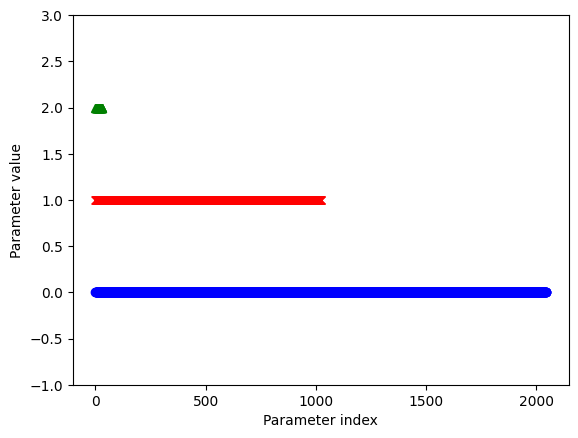

In [ ]:
# Change the weights before training
net_allzero,lossfun,optimizer = mnist_1()

# loop over parameters and set them all to zeros
for p in net_allzero.named_parameters():
  p[1].data = torch.zeros_like( p[1].data )


# and confirm for a few select parameters (y-axis offset for visibility)
plt.plot(0+net_allzero.fc1.weight.data.flatten(),'bo')
plt.plot(1+net_allzero.fc2.weight.data.flatten(),'rx')
plt.plot(2+net_allzero.fc1.bias.data.flatten(),'g^')
plt.xlabel('Parameter index')
plt.ylim([-1,3])
plt.ylabel('Parameter value')
plt.show()

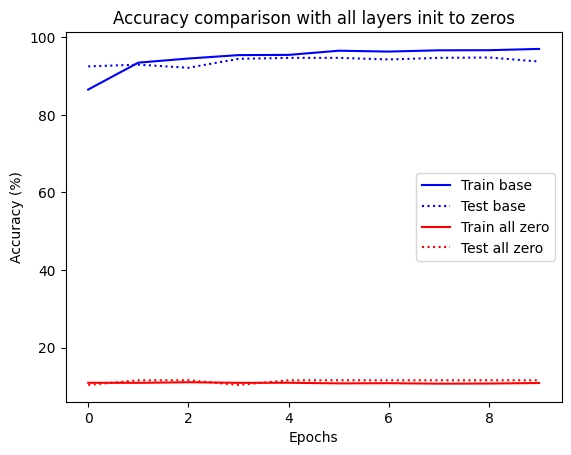

In [ ]:
# run the model and show the results
trainAcc_allzero,testAcc_allzero,losses,net_allzero = train_1(net_allzero,lossfun,optimizer)

plt.plot(range(len(trainAcc_base)),trainAcc_base,'b-', range(len(testAcc_base)),testAcc_base ,'b:')
plt.plot(range(len(trainAcc_allzero)),trainAcc_allzero,'r-', range(len(testAcc_allzero)),testAcc_allzero ,'r:')
plt.legend(['Train base','Test base','Train all zero','Test all zero'])
plt.title('Accuracy comparison with all layers init to zeros')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.show()

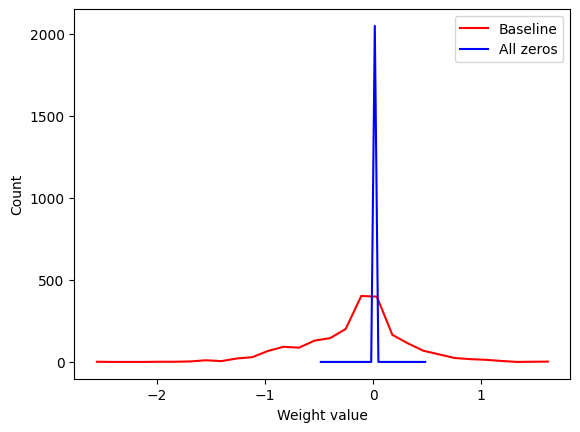

In [ ]:
# show the distributions in a histogram
y,x = np.histogram(net_base.fc1.weight.data.flatten(),30)
plt.plot((x[1:]+x[:-1])/2,y,'r',label='Baseline')

y,x = np.histogram(net_allzero.fc1.weight.data.flatten(),30)
plt.plot((x[1:]+x[:-1])/2,y,'b',label='All zeros')

plt.legend()
plt.xlabel('Weight value')
plt.ylabel('Count')
plt.show()
#baseline model has a better distribution

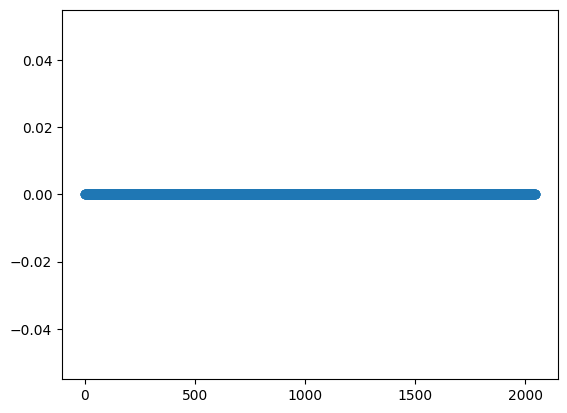

In [ ]:
# woah, not even a single non-zero weight value?!?!!?!!??
plt.plot(net_allzero.fc1.weight.data.flatten(),'o');

In [ ]:
for p in net_allone.named_parameters():
  print(p[0])

input.weight
input.bias
fc1.weight
fc1.bias
fc2.weight
fc2.bias
output.weight
output.bias


In [ ]:
# Change the weights before training
net_allone,lossfun,optimizer = mnist_1()
for p in net_allone.named_parameters():
  print("p",p[1])
  p[1].data = torch.zeros_like( p[1].data ) + 1
  #p[1].data = torch.zeros( p[1].data.shape ) + 1 # equivalent to the previous line!

p Parameter containing:
tensor([[ 0.0024,  0.0316,  0.0261,  ..., -0.0307, -0.0296,  0.0098],
        [ 0.0251,  0.0174,  0.0260,  ..., -0.0043,  0.0192,  0.0066],
        [ 0.0351,  0.0338,  0.0167,  ...,  0.0089,  0.0300,  0.0046],
        ...,
        [-0.0160, -0.0246, -0.0116,  ...,  0.0350, -0.0209,  0.0007],
        [ 0.0170, -0.0155, -0.0169,  ...,  0.0216, -0.0215, -0.0087],
        [ 0.0119,  0.0263,  0.0225,  ...,  0.0154,  0.0056,  0.0305]],
       requires_grad=True)
p Parameter containing:
tensor([-3.1624e-02,  5.5938e-03,  2.8075e-02, -5.5895e-03,  2.7749e-02,
        -7.0369e-04,  3.4354e-02,  3.4594e-02, -3.3923e-02,  1.8468e-02,
        -2.1402e-03, -1.5553e-02, -3.5269e-02,  3.0031e-02, -2.0988e-02,
         5.7941e-03,  2.0726e-02,  3.1890e-02,  2.8481e-02,  2.8809e-02,
         1.1824e-02, -3.3460e-02, -1.6914e-02, -1.3193e-02, -8.3283e-03,
         2.1387e-02, -2.9421e-02, -3.5478e-02, -2.5917e-02,  1.9033e-02,
        -4.9605e-03, -2.8983e-02,  2.0862e-03,  1.598

p input.weight Parameter containing:
tensor([[-0.0201,  0.0180, -0.0129,  ..., -0.0213,  0.0128,  0.0275],
        [ 0.0060,  0.0138, -0.0277,  ..., -0.0086, -0.0022,  0.0126],
        [ 0.0277, -0.0243,  0.0278,  ...,  0.0053,  0.0324, -0.0305],
        ...,
        [-0.0315,  0.0207,  0.0292,  ..., -0.0099,  0.0005,  0.0349],
        [ 0.0292, -0.0008,  0.0223,  ..., -0.0165,  0.0274,  0.0343],
        [ 0.0133,  0.0074, -0.0155,  ..., -0.0313, -0.0074, -0.0001]],
       requires_grad=True)
p input.bias Parameter containing:
tensor([ 0.0153, -0.0273,  0.0075, -0.0345,  0.0294, -0.0013, -0.0110, -0.0116,
        -0.0170, -0.0329,  0.0010, -0.0058,  0.0249, -0.0200, -0.0356,  0.0064,
         0.0299,  0.0104,  0.0186, -0.0234,  0.0260, -0.0314, -0.0060, -0.0184,
         0.0187,  0.0101, -0.0301, -0.0190,  0.0046,  0.0150, -0.0088,  0.0302,
        -0.0096,  0.0226,  0.0263,  0.0172, -0.0326, -0.0225,  0.0055, -0.0135,
         0.0178,  0.0126, -0.0042, -0.0180,  0.0217, -0.0222,  0.02

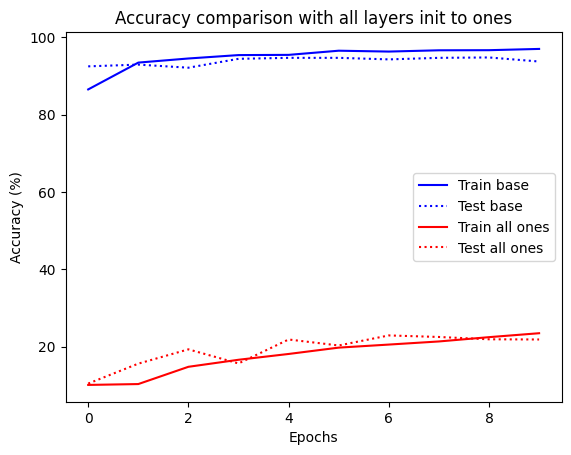

In [ ]:
# Change the weights before training
net_allone,lossfun,optimizer = mnist_1()
for p in net_allone.named_parameters():
  print("p",p[0],p[1])
  p[1].data = torch.zeros_like( p[1].data ) + 1
  #p[1].data = torch.zeros( p[1].data.shape ) + 1 # equivalent to the previous line!

# run the model and show the results
trainAcc_allone,testAcc_allone,losses,net_allone = train_1(net_allone,lossfun,optimizer)

plt.plot(range(len(trainAcc_base)),trainAcc_base,'b-', range(len(testAcc_base)),testAcc_base ,'b:')
plt.plot(range(len(trainAcc_allone)),trainAcc_allone,'r-', range(len(testAcc_allone)),testAcc_allone ,'r:')
plt.legend(['Train base','Test base','Train all ones','Test all ones'])
plt.title('Accuracy comparison with all layers init to ones')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.show()

p Parameter containing:
tensor([[-0.0045,  0.0075, -0.0070,  ...,  0.0105, -0.0281,  0.0142],
        [-0.0119, -0.0343,  0.0070,  ...,  0.0179, -0.0335, -0.0172],
        [ 0.0220,  0.0335,  0.0179,  ...,  0.0312,  0.0086, -0.0330],
        ...,
        [ 0.0148, -0.0217,  0.0305,  ..., -0.0119, -0.0201,  0.0117],
        [-0.0333, -0.0191,  0.0118,  ..., -0.0080,  0.0146, -0.0091],
        [-0.0168,  0.0179,  0.0266,  ..., -0.0119,  0.0066, -0.0171]],
       requires_grad=True)
p Parameter containing:
tensor([-0.0110,  0.0304, -0.0258,  0.0248, -0.0212, -0.0095,  0.0275,  0.0086,
        -0.0226,  0.0012,  0.0137,  0.0296, -0.0140,  0.0224, -0.0101, -0.0192,
        -0.0001,  0.0181,  0.0177, -0.0080,  0.0165,  0.0245,  0.0234,  0.0004,
        -0.0115, -0.0350, -0.0025, -0.0130, -0.0012, -0.0087,  0.0126,  0.0200,
         0.0089,  0.0203,  0.0201,  0.0159, -0.0278,  0.0270,  0.0182, -0.0086,
         0.0335, -0.0223, -0.0181, -0.0129,  0.0307, -0.0350, -0.0169, -0.0316,
        -0.

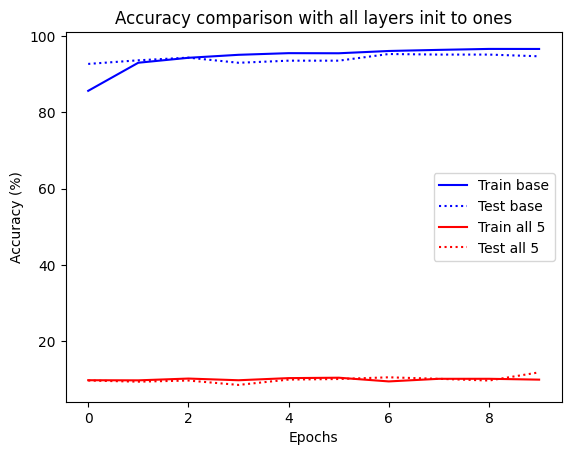

In [ ]:
# Change the weights before training
net_allone,lossfun,optimizer = mnist_1()
for p in net_allone.named_parameters():
  print("p",p[1])
  p[1].data = torch.zeros_like( p[1].data ) + 5


# run the model and show the results
trainAcc_allone,testAcc_allone,losses,net_allone = train_1(net_allone,lossfun,optimizer)

plt.plot(range(len(trainAcc_base)),trainAcc_base,'b-', range(len(testAcc_base)),testAcc_base ,'b:')
plt.plot(range(len(trainAcc_allone)),trainAcc_allone,'r-', range(len(testAcc_allone)),testAcc_allone ,'r:')
plt.legend(['Train base','Test base','Train all 5','Test all 5'])
plt.title('Accuracy comparison with all layers init to ones')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.show()

### Understanding `weight` vs `parameters()`

*   **`model_1[i].weight`**: This directly accesses the `weight` attribute of a specific layer in your `nn.Sequential` model. It returns the `torch.Tensor` representing the weights for that layer.

*   **`model_1[i].parameters()`**: This is a method that returns an *iterator* over all the parameters (including both `weight` and `bias` if `bias=True` for that layer) of a specific layer. It's commonly used when you want to iterate through all trainable parameters for optimization, e.g., when passing them to an optimizer.

Let's see them in action:

In [ ]:
# Accessing the weight tensor of the first layer
print("model_1[0].weight:")
print(model_1[0].weight)
print(f"Type of model_1[0].weight: {type(model_1[0].weight)}")
print(f"Shape of model_1[0].weight: {model_1[0].weight.shape}")

model_1[0].weight:
Parameter containing:
tensor([[ 0.2473,  0.0421, -0.2448, -0.0700,  0.0427, -0.1539,  0.1429, -0.2247,
          0.1348, -0.2120],
        [-0.2926,  0.1412,  0.1948, -0.0460,  0.2579,  0.0829,  0.1690,  0.2828,
         -0.1925,  0.2596],
        [ 0.0034, -0.3100,  0.2437, -0.2231,  0.3079,  0.1802,  0.1269, -0.1070,
         -0.2523, -0.0324],
        [ 0.1745,  0.1506, -0.1483, -0.0159, -0.1241,  0.2389, -0.2327, -0.1700,
         -0.1233,  0.0298],
        [ 0.0593,  0.0205, -0.2882, -0.1095,  0.0914,  0.3033, -0.2574,  0.0817,
         -0.1630, -0.1212],
        [-0.2395, -0.2763,  0.0178, -0.0974,  0.1571, -0.0798,  0.1029, -0.1538,
         -0.1726,  0.2729],
        [-0.2298, -0.1953, -0.0537, -0.0480, -0.0459,  0.2242, -0.0778, -0.0150,
          0.1755,  0.1077],
        [ 0.1579,  0.1948,  0.2788, -0.3007,  0.0615, -0.2258,  0.0760, -0.3019,
          0.2946, -0.0903],
        [-0.2536, -0.1933,  0.1509, -0.2162,  0.1642,  0.3010, -0.2010,  0.0100,
      

In [ ]:
# Accessing the parameters (weight and bias) of the first layer
print("model_1[0].parameters():")
for name, param in model_1[0].named_parameters():
    print(f"  Parameter name: {name}, shape: {param.shape}")
    if name == 'weight':
        # Verify that it's the same weight tensor
        assert torch.equal(param, model_1[0].weight)
        print("  (This is the same weight tensor as above)")
    elif name == 'bias':
        print("  (This is the bias tensor)")

model_1[0].parameters():
  Parameter name: weight, shape: torch.Size([14, 10])
  (This is the same weight tensor as above)
  Parameter name: bias, shape: torch.Size([14])
  (This is the bias tensor)


# Xavier Initialization